In [1]:
from doc_parser import DocParser
import os
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY')
import asyncio

doc_parser = DocParser(
    input_dir='/Users/ivankoh/work/chatpdf/datasets/osv_dataset/pitch_decks',
    output_dir='/Users/ivankoh/work/chatpdf/backend/page_contents',
    openai_api_key=OPENAI_API_KEY,
    model_path='best.pt'
)


In [2]:
await doc_parser.parse_directory()


0: 384x640 (no detections), 84.7ms
Speed: 2.0ms preprocess, 84.7ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 graph, 56.2ms
Speed: 1.0ms preprocess, 56.2ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 49.7ms
Speed: 3.2ms preprocess, 49.7ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 graph, 40.6ms
Speed: 1.3ms preprocess, 40.6ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 67.0ms
Speed: 1.4ms preprocess, 67.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 60.8ms
Speed: 1.1ms preprocess, 60.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 82.1ms
Speed: 2.6ms preprocess, 82.1ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 43.0ms
Speed: 1.1ms preprocess, 43.0ms inference, 0.2ms 

CancelledError: 

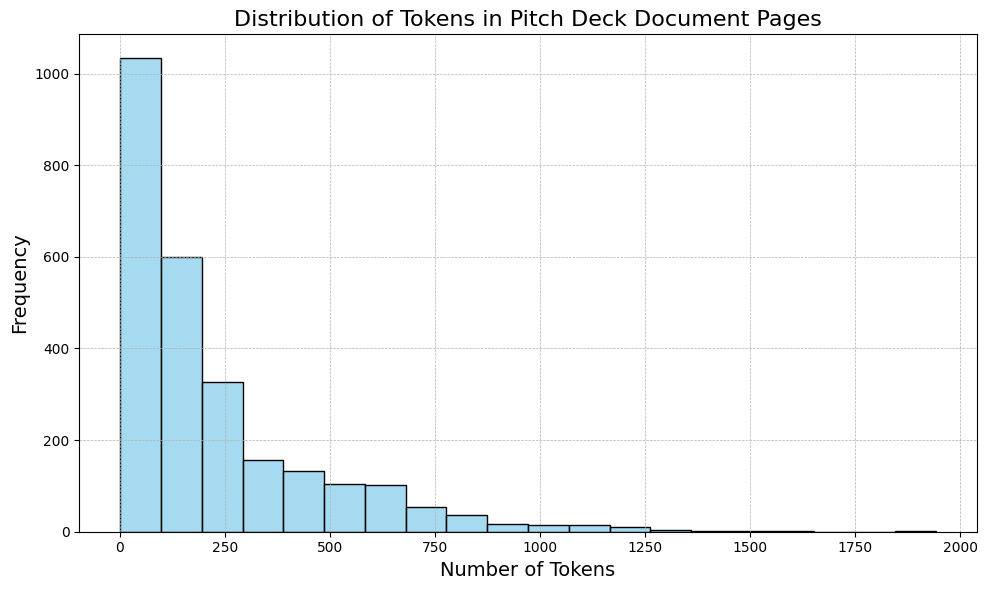

In [8]:
# max input = 8191
# https://platform.openai.com/docs/guides/embeddings/embedding-models

import tiktoken

def num_tokens_from_string(string: str, encoding_name: str='cl100k_base') -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# token analysis 
page_contents_directory_path = "/Users/ivankoh/work/chatpdf/backend/page_contents"
# flatten all the files in the directory
all_files = []
for root, dirs, files in os.walk(page_contents_directory_path):
    for file in files:
        all_files.append(os.path.join(root, file))

# get the number of tokens for each file
num_tokens = []
for file in all_files:
    with open(file, 'r') as f:
        content = f.read()
    num_tokens.append(num_tokens_from_string(content))
num_tokens = [x for x in num_tokens if x > 0]

import seaborn as sns
import matplotlib.pyplot as plt

# Relabeling the axis and improving the plot aesthetics
plt.figure(figsize=(10, 6))
sns.histplot(num_tokens, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Tokens in Pitch Deck Document Pages', fontsize=16)
plt.xlabel('Number of Tokens', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
